# 03 — Error Analysis

**Студент:** Олександр Щепанчук &nbsp;&nbsp; **Група:** ПМПм-12

Optional deep-dive on misclassified edges. Embedded figures and tables come from `scripts/export_report_assets.py`. If the export step hasn't run, every cell prints a clear *Run `make all` first* message.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from reddit_gnn.paths import PATHS

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

EDGES_PATH = PATHS.data_processed / 'edges.parquet'
META_PATH = PATHS.data_processed / 'metadata.json'
N2I_PATH = PATHS.data_processed / 'node_to_id.json'
FIG_DIR = PATHS.reports_figures
TBL_DIR = PATHS.reports_tables

def show_image_or_msg(path: Path, label: str = '') -> None:
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path)))
        print(f'shown: {path}')
    else:
        print(f'Missing — run `make all` first: {path}')

def load_table_or_msg(path: Path, **read_kwargs) -> pd.DataFrame | None:
    path = Path(path)
    if not path.exists():
        print(f'Missing — run `make all` first: {path}')
        return None
    return pd.read_csv(path, **read_kwargs)

## Confusion-matrix examples per architecture

Sample rows from each of the four confusion-matrix cells (TN, FP, FN, TP) per run. Useful for qualitative inspection of the kinds of edges each model confuses.

In [2]:
for csv in sorted(TBL_DIR.glob('confusion_examples_*.csv')):
    print(csv.name)
    display(pd.read_csv(csv).groupby('cell').head(3))
if not list(TBL_DIR.glob('confusion_examples_*.csv')):
    print('No confusion-examples tables yet — run `make all` then `uv run python scripts/export_report_assets.py`.')

confusion_examples_baseline_logreg-20260513-235620.csv


,split,source_id,target_id,timestamp,y_true,y_score,y_pred,source_subreddit_norm,target_subreddit_norm,cell
0,test,1415,57881,2016-12-21 18:56:16,0,0.499129,0,sr_1415,sr_57881,true_0_pred_0
1,test,65855,12544,2017-03-31 03:57:22,0,0.493457,0,sr_65855,sr_12544,true_0_pred_0
2,test,10989,23560,2016-12-22 10:21:51,0,0.449305,0,sr_10989,sr_23560,true_0_pred_0
10,test,29732,27319,2017-04-03 00:35:40,0,0.506366,1,sr_29732,sr_27319,true_0_pred_1
11,test,4901,3934,2017-02-07 01:41:19,0,0.549060,1,sr_4901,sr_3934,true_0_pred_1
12,test,57119,32023,2017-02-02 00:53:31,0,0.533362,1,sr_57119,sr_32023,true_0_pred_1
20,test,35481,61641,2017-03-21 12:26:09,1,0.411986,0,sr_35481,sr_61641,true_1_pred_0
21,test,51781,2410,2017-03-29 13:53:24,1,0.467610,0,sr_51781,sr_2410,true_1_pred_0
22,test,65130,65615,2017-01-19 21:21:51,1,0.479149,0,sr_65130,sr_65615,true_1_pred_0
30,test,53006,42750,2017-04-26 13:57:22,1,0.502366,1,sr_53006,sr_42750,true_1_pred_1


confusion_examples_baseline_mlp-20260514-000355.csv


,split,source_id,target_id,timestamp,y_true,y_score,y_pred,source_subreddit_norm,target_subreddit_norm,cell
0,test,14683,7252,2016-12-21 16:11:14,0,1.521384e-38,0,sr_14683,sr_7252,true_0_pred_0
1,test,1415,7252,2017-03-30 04:13:27,0,2.763250e-29,0,sr_1415,sr_7252,true_0_pred_0
2,test,30759,65825,2016-12-22 00:19:45,0,1.504680e-16,0,sr_30759,sr_65825,true_0_pred_0
10,test,55640,39309,2017-04-04 11:10:51,0,1.000000e+00,1,sr_55640,sr_39309,true_0_pred_1
11,test,43294,43266,2017-02-08 13:54:25,0,9.999802e-01,1,sr_43294,sr_43266,true_0_pred_1
12,test,47895,42750,2017-02-03 14:47:01,0,6.113406e-01,1,sr_47895,sr_42750,true_0_pred_1
20,test,51917,50111,2017-03-18 20:40:55,1,0.000000e+00,0,sr_51917,sr_50111,true_1_pred_0
21,test,55883,38638,2017-03-27 07:57:30,1,0.000000e+00,0,sr_55883,sr_38638,true_1_pred_0
22,test,13298,52376,2017-01-20 18:10:02,1,6.047003e-33,0,sr_13298,sr_52376,true_1_pred_0
30,test,1666,16406,2017-04-26 22:25:56,1,1.000000e+00,1,sr_1666,sr_16406,true_1_pred_1


confusion_examples_baseline_mlp-seed0.csv


...

,split,source_id,target_id,timestamp,y_true,y_score,y_pred,source_subreddit_norm,target_subreddit_norm,cell
0,test,30536,63613,2016-12-21 18:34:30,0,0.156049,0,sr_30536,sr_63613,true_0_pred_0
1,test,19060,19510,2017-03-31 09:49:13,0,0.104092,0,sr_19060,sr_19510,true_0_pred_0
2,test,10530,4017,2016-12-22 09:46:25,0,0.389952,0,sr_10530,sr_4017,true_0_pred_0
10,test,30132,44878,2017-04-03 18:07:09,0,0.940976,1,sr_30132,sr_44878,true_0_pred_1
11,test,64929,22784,2017-02-07 01:50:10,0,0.639636,1,sr_64929,sr_22784,true_0_pred_1
12,test,50111,58969,2017-02-02 13:56:44,0,0.578460,1,sr_50111,sr_58969,true_0_pred_1
20,test,42046,21574,2017-03-19 18:43:11,1,0.488214,0,sr_42046,sr_21574,true_1_pred_0
21,test,42091,12309,2017-03-28 05:23:24,1,0.368820,0,sr_42091,sr_12309,true_1_pred_0
22,test,42091,12309,2017-01-18 00:30:53,1,0.368820,0,sr_42091,sr_12309,true_1_pred_0
30,test,46634,3757,2017-04-26 15:18:54,1,0.804692,1,sr_46634,sr_3757,true_1_pred_1


confusion_examples_sage-seed1.csv


,split,source_id,target_id,timestamp,y_true,y_score,y_pred,source_subreddit_norm,target_subreddit_norm,cell
0,test,27361,30311,2016-12-22 07:50:20,0,0.172410,0,sr_27361,sr_30311,true_0_pred_0
1,test,17084,4017,2017-03-31 12:42:37,0,0.298308,0,sr_17084,sr_4017,true_0_pred_0
2,test,51860,57881,2016-12-22 17:49:51,0,0.213682,0,sr_51860,sr_57881,true_0_pred_0
10,test,20984,56303,2017-04-02 17:36:41,0,0.592681,1,sr_20984,sr_56303,true_0_pred_1
11,test,41359,27319,2017-02-04 23:27:04,0,0.919959,1,sr_41359,sr_27319,true_0_pred_1
12,test,19060,63613,2017-01-30 18:07:49,0,0.547753,1,sr_19060,sr_63613,true_0_pred_1
20,test,42338,22153,2017-03-21 17:37:21,1,0.458221,0,sr_42338,sr_22153,true_1_pred_0
21,test,18476,2410,2017-03-30 01:52:58,1,0.330967,0,sr_18476,sr_2410,true_1_pred_0
22,test,12544,63613,2017-01-20 05:54:27,1,0.486501,0,sr_12544,sr_63613,true_1_pred_0
30,test,51860,15210,2017-04-26 13:50:03,1,0.859317,1,sr_51860,sr_15210,true_1_pred_1


confusion_examples_sage-seed2.csv


,split,source_id,target_id,timestamp,y_true,y_score,y_pred,source_subreddit_norm,target_subreddit_norm,cell
0,test,51835,23560,2016-12-21 22:53:30,0,0.397026,0,sr_51835,sr_23560,true_0_pred_0
1,test,60010,66779,2017-03-31 14:17:16,0,0.448728,0,sr_60010,sr_66779,true_0_pred_0
2,test,10989,22300,2016-12-22 13:38:10,0,0.111198,0,sr_10989,sr_22300,true_0_pred_0
10,test,43774,1348,2017-04-02 15:30:14,0,0.543152,1,sr_43774,sr_1348,true_0_pred_1
11,test,26729,40057,2017-02-06 06:22:22,0,0.763402,1,sr_26729,sr_40057,true_0_pred_1
12,test,45651,45636,2017-02-01 00:21:46,0,0.696828,1,sr_45651,sr_45636,true_0_pred_1
20,test,59881,22300,2017-03-20 11:14:08,1,0.323407,0,sr_59881,sr_22300,true_1_pred_0
21,test,23211,23117,2017-03-28 21:01:08,1,0.324718,0,sr_23211,sr_23117,true_1_pred_0
22,test,25871,39739,2017-01-19 19:57:16,1,0.278608,0,sr_25871,sr_39739,true_1_pred_0
30,test,7419,45908,2017-04-26 13:09:22,1,0.613193,1,sr_7419,sr_45908,true_1_pred_1


## By-time error rate

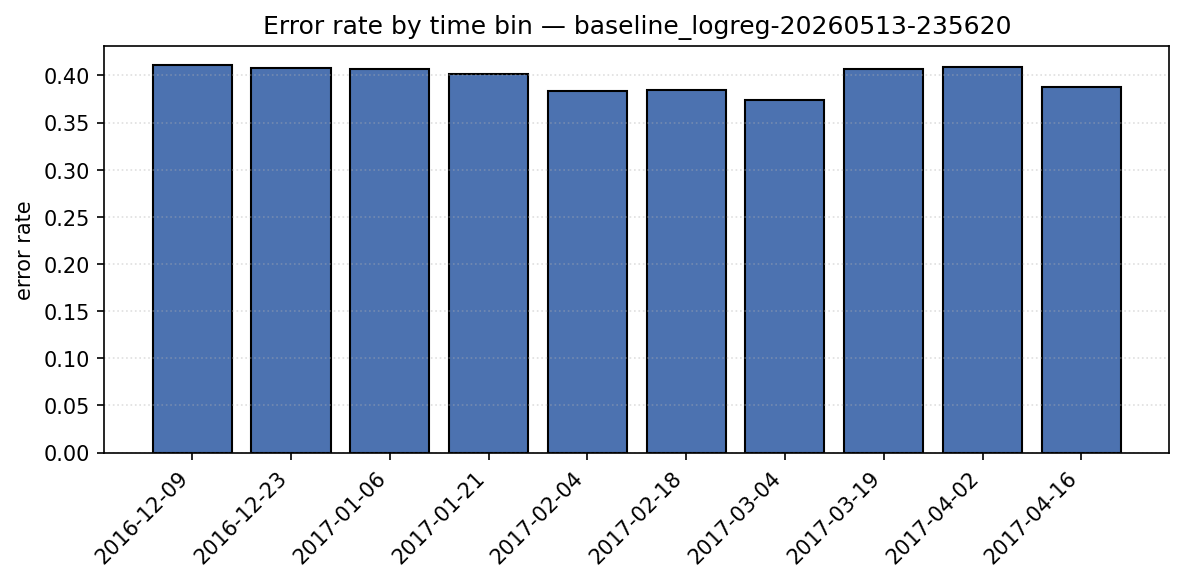

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_baseline_logreg-20260513-235620.png


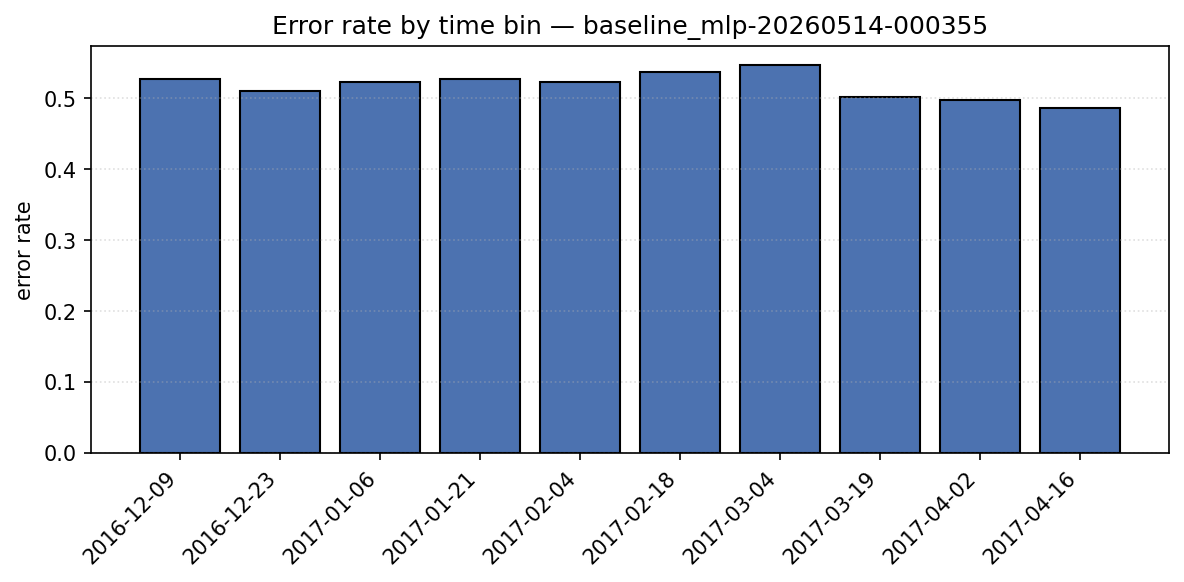

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_baseline_mlp-20260514-000355.png


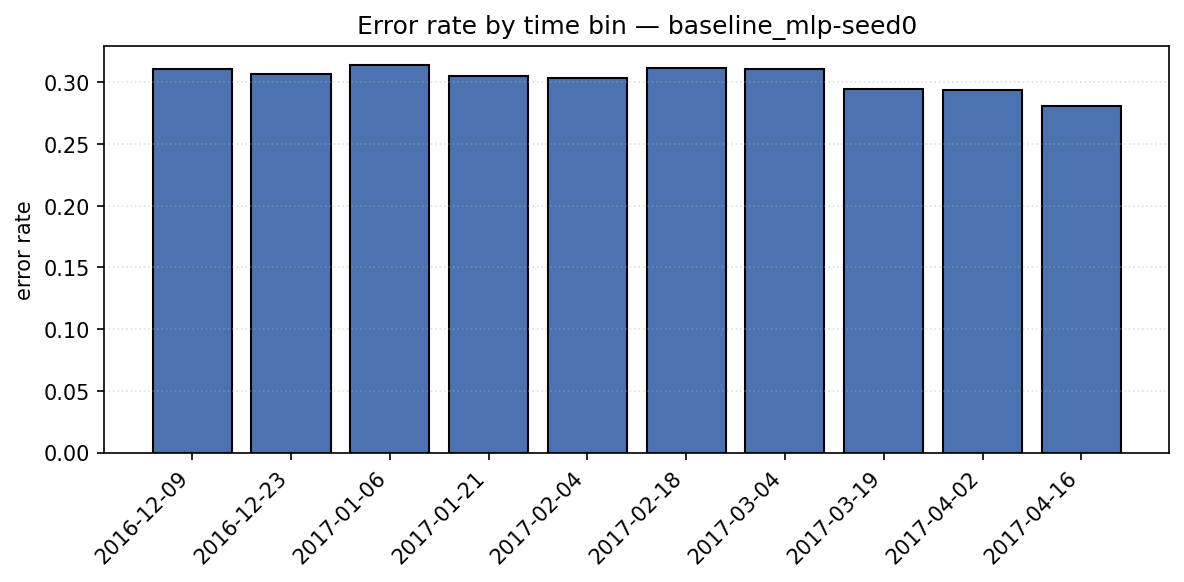

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_baseline_mlp-seed0.png


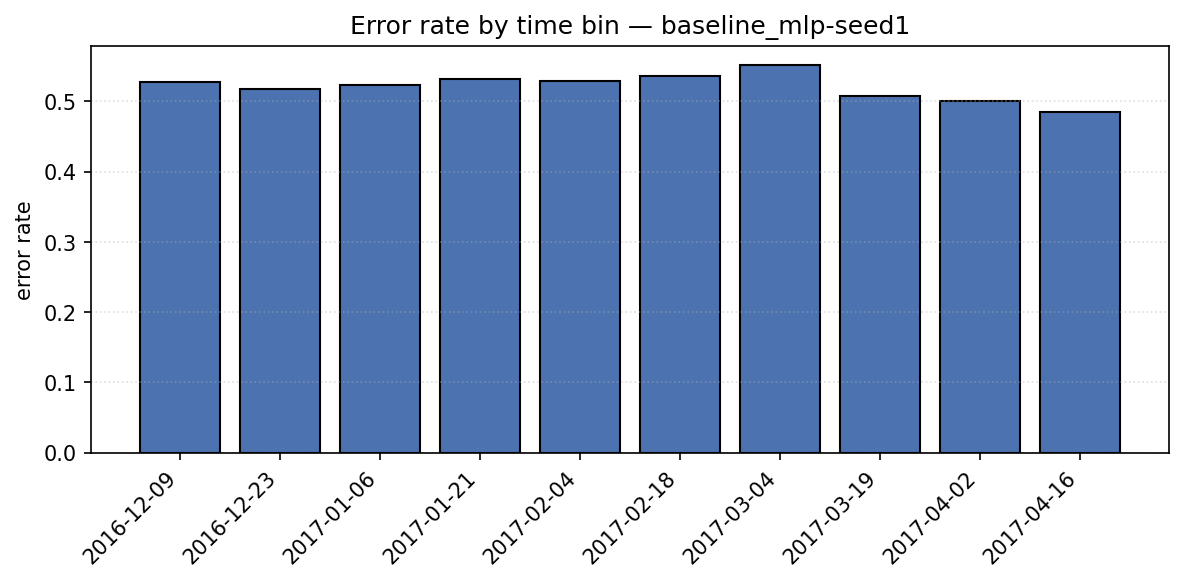

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_baseline_mlp-seed1.png


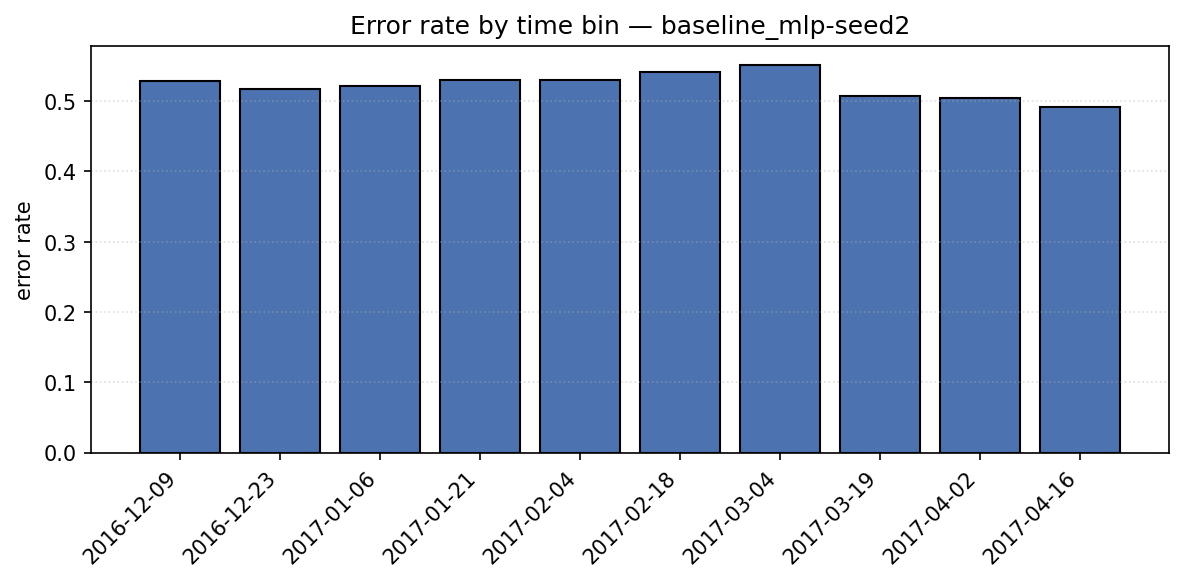

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_baseline_mlp-seed2.png


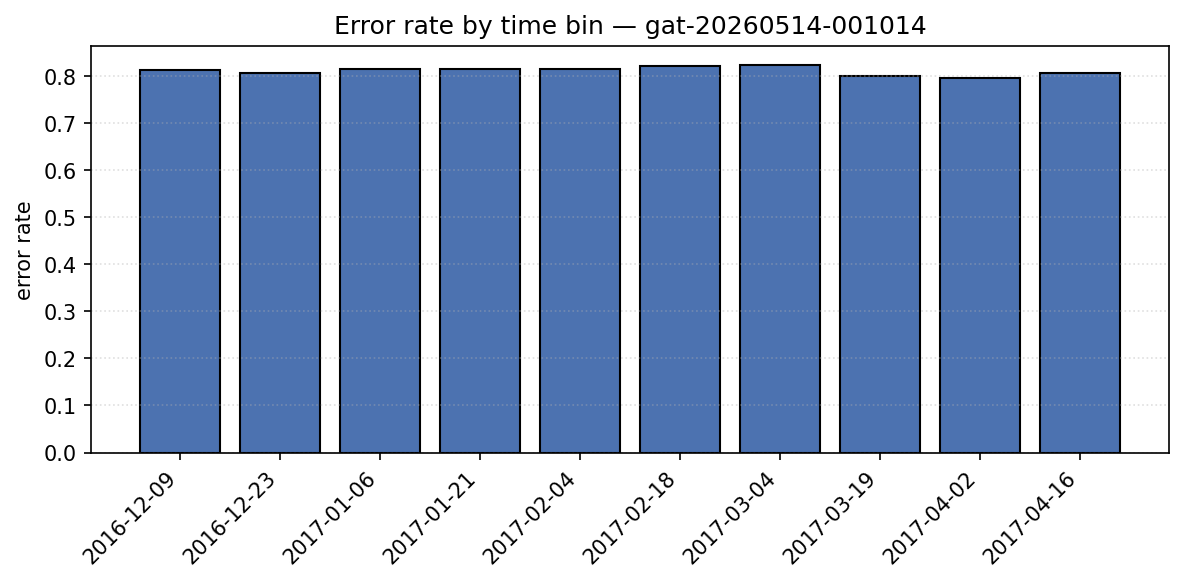

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_gat-20260514-001014.png


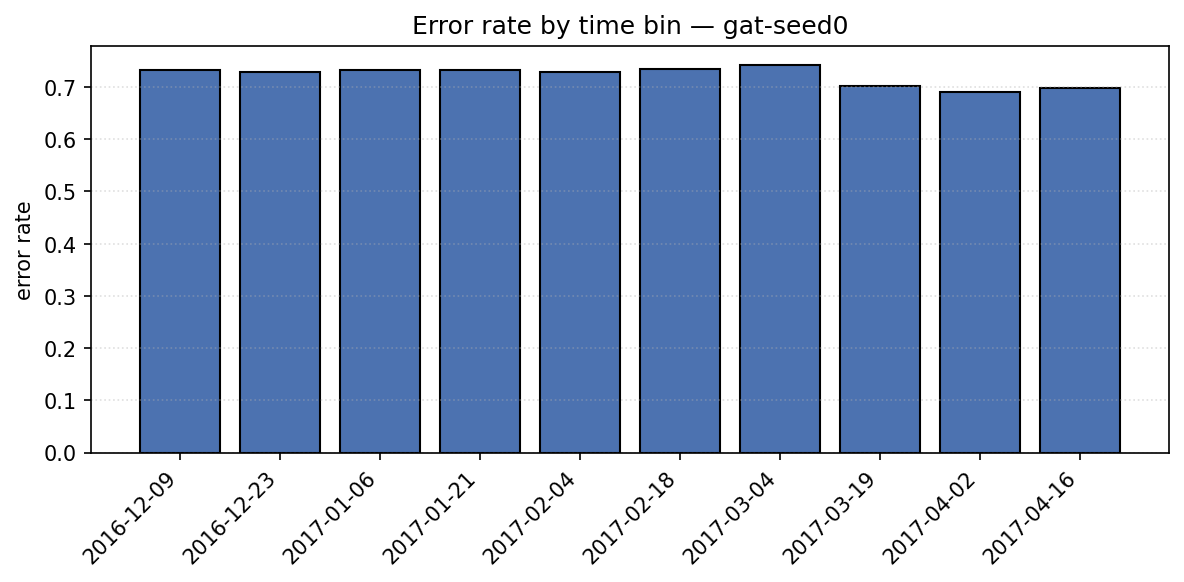

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_gat-seed0.png


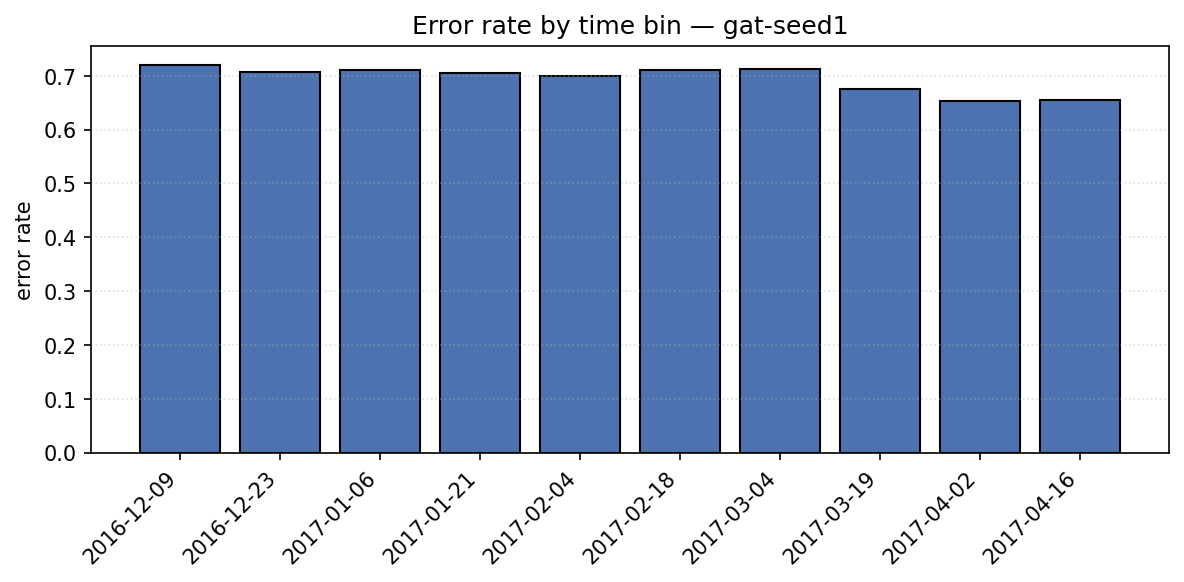

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_gat-seed1.png


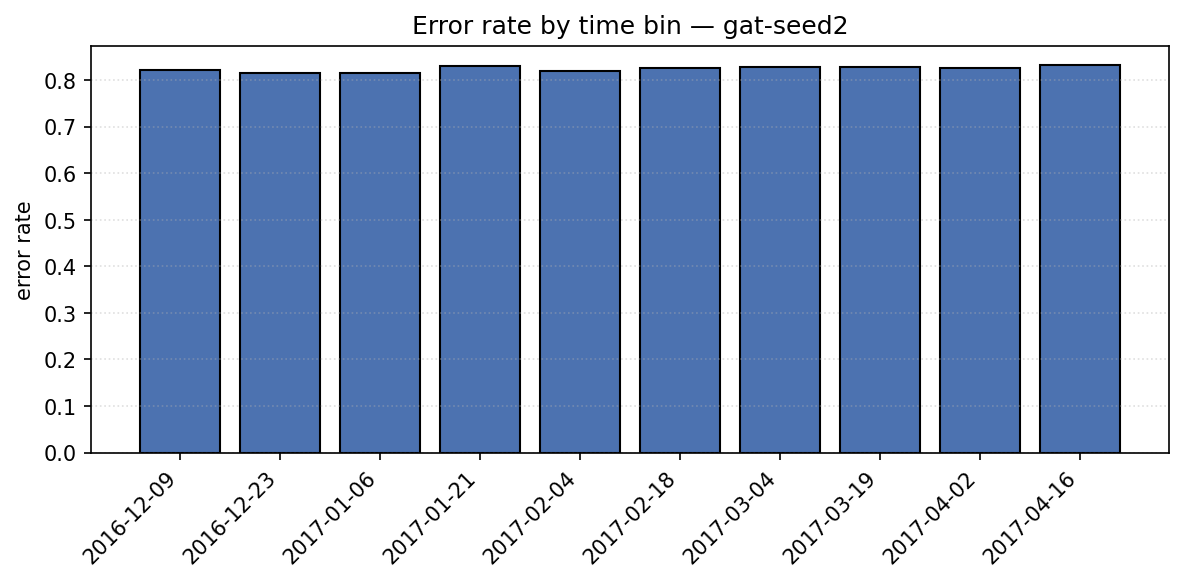

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_gat-seed2.png


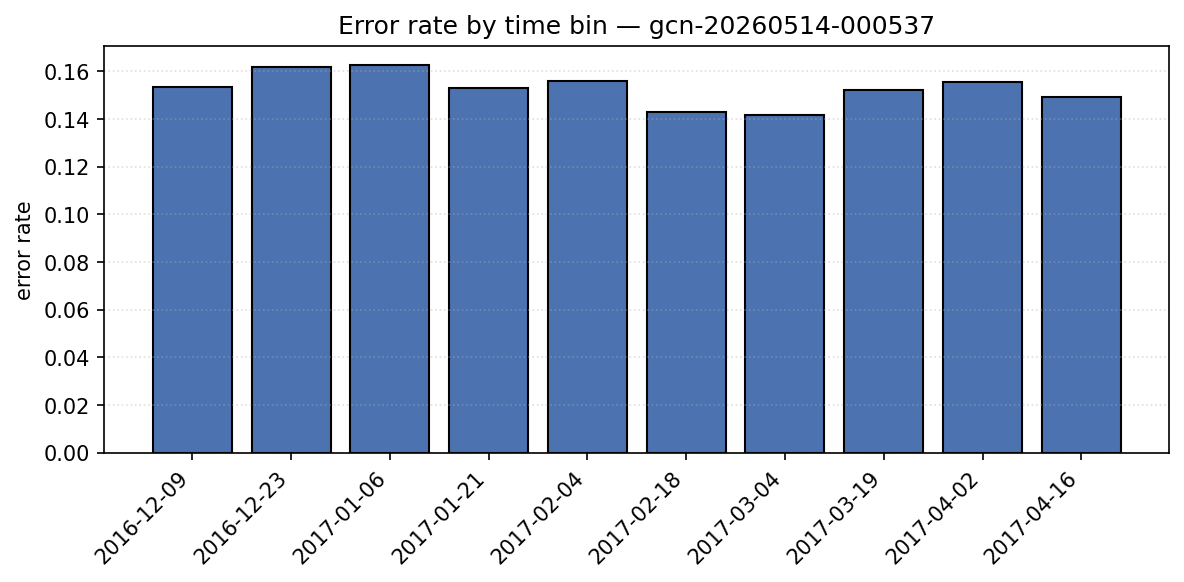

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_gcn-20260514-000537.png


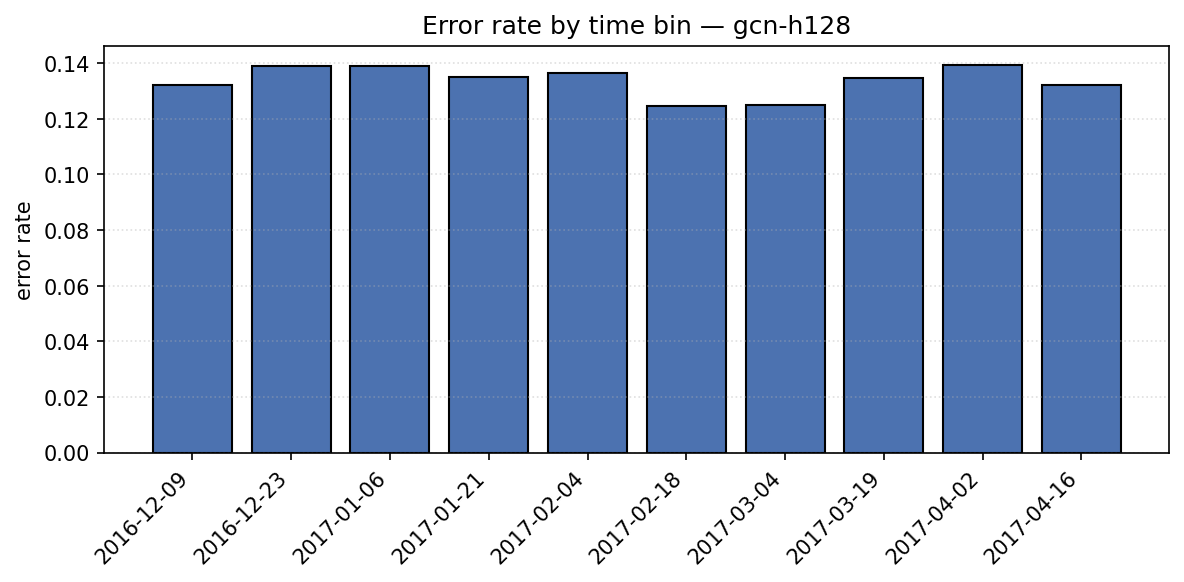

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_gcn-h128.png


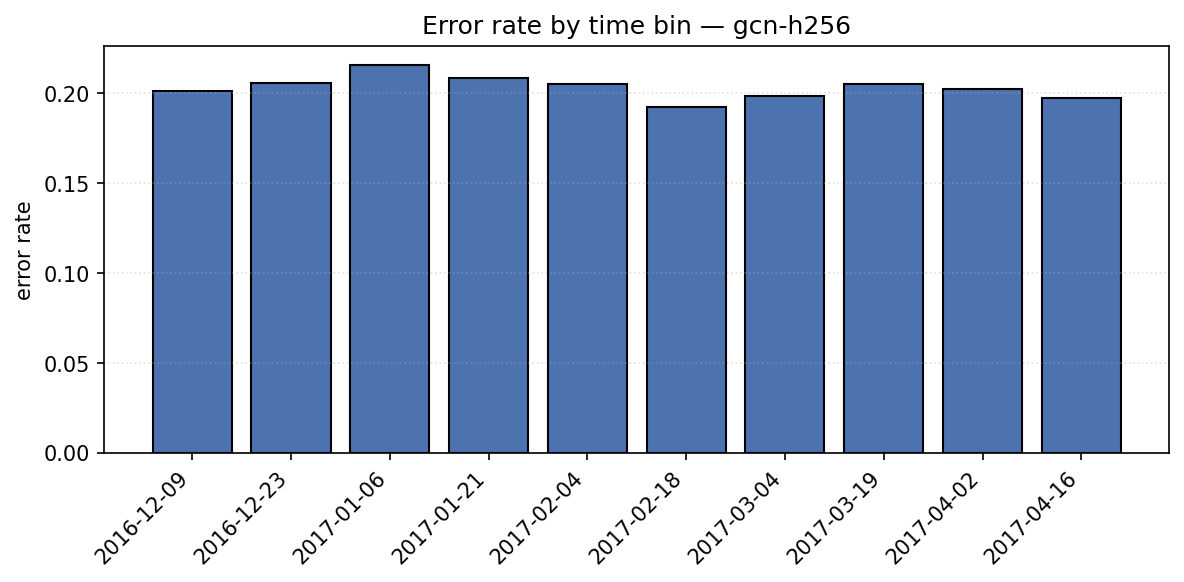

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_gcn-h256.png


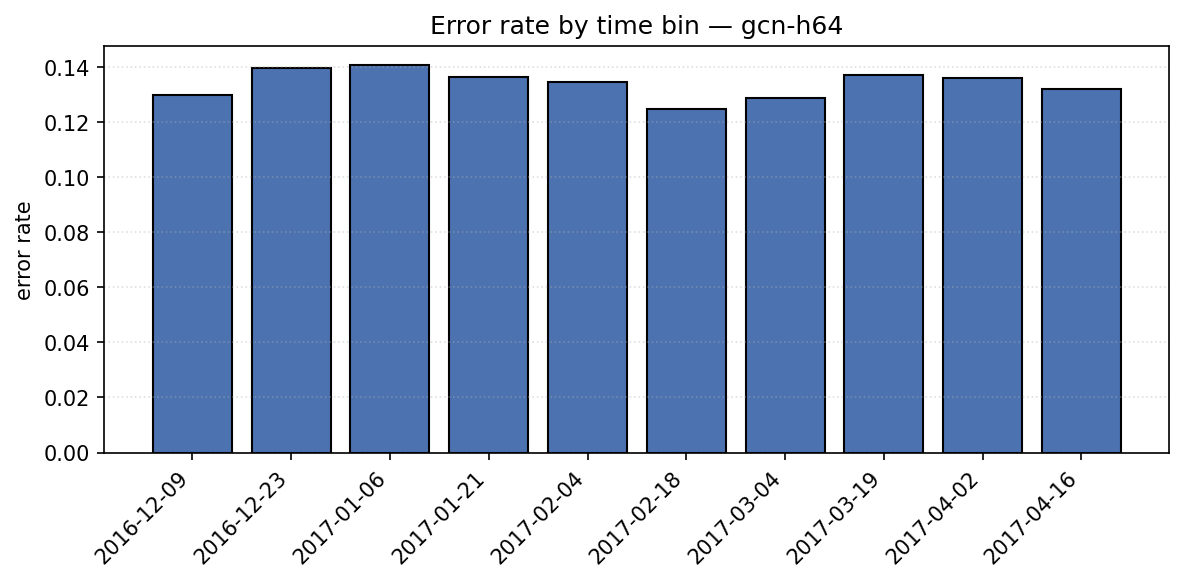

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_gcn-h64.png


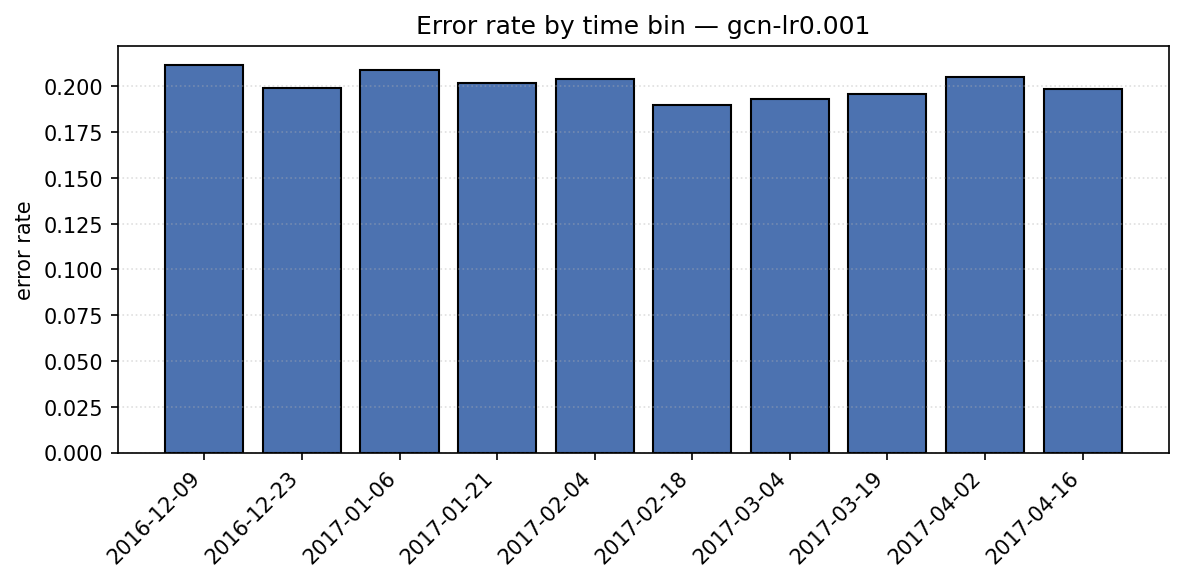

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_gcn-lr0.001.png


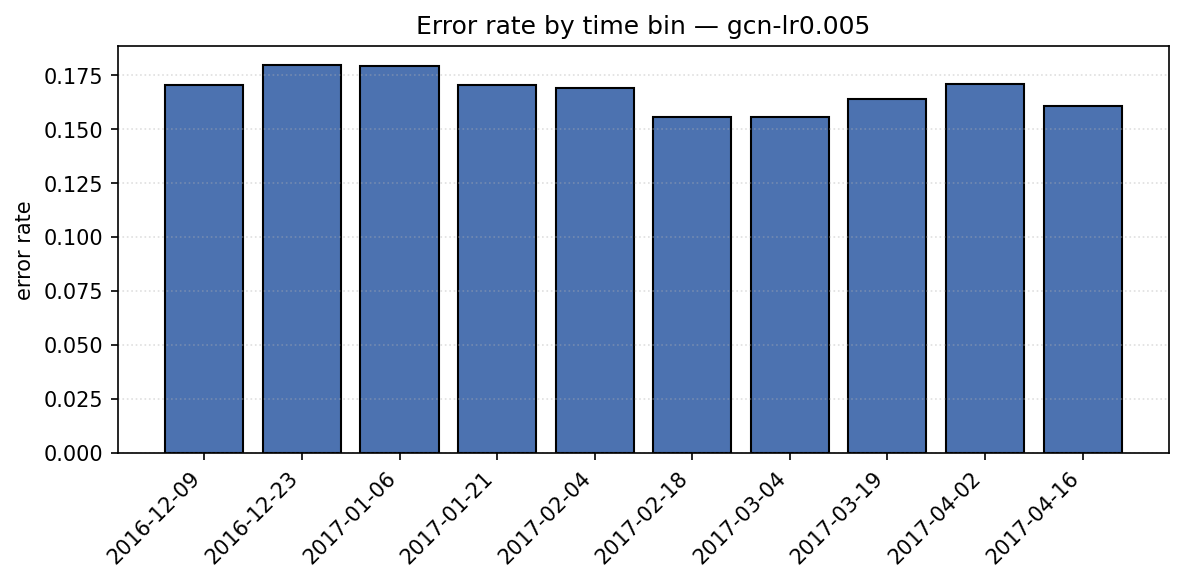

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_gcn-lr0.005.png


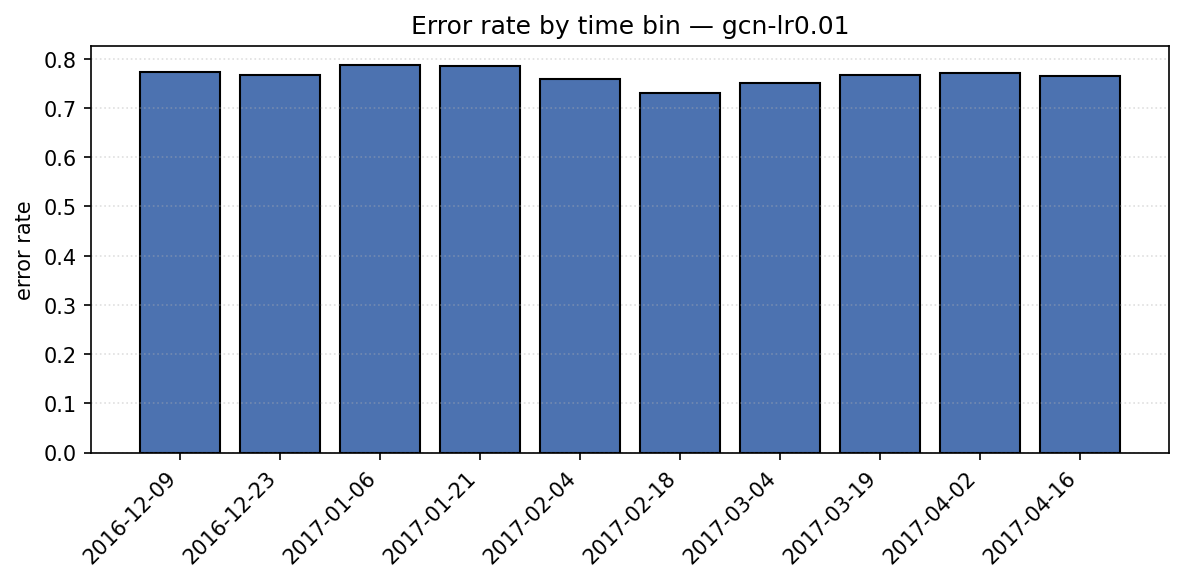

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_gcn-lr0.01.png


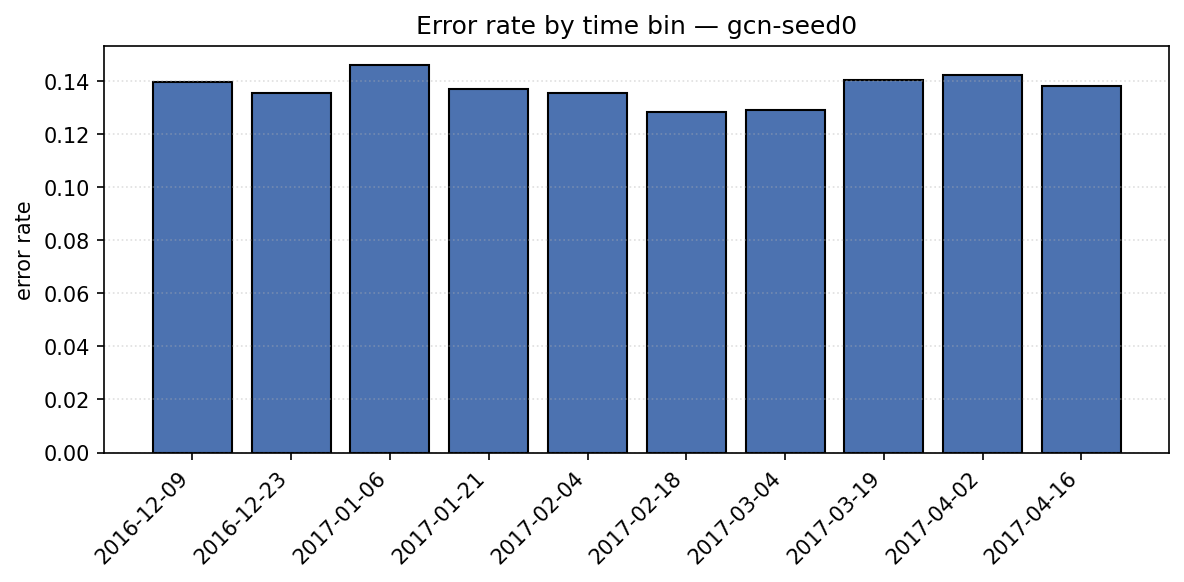

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_gcn-seed0.png


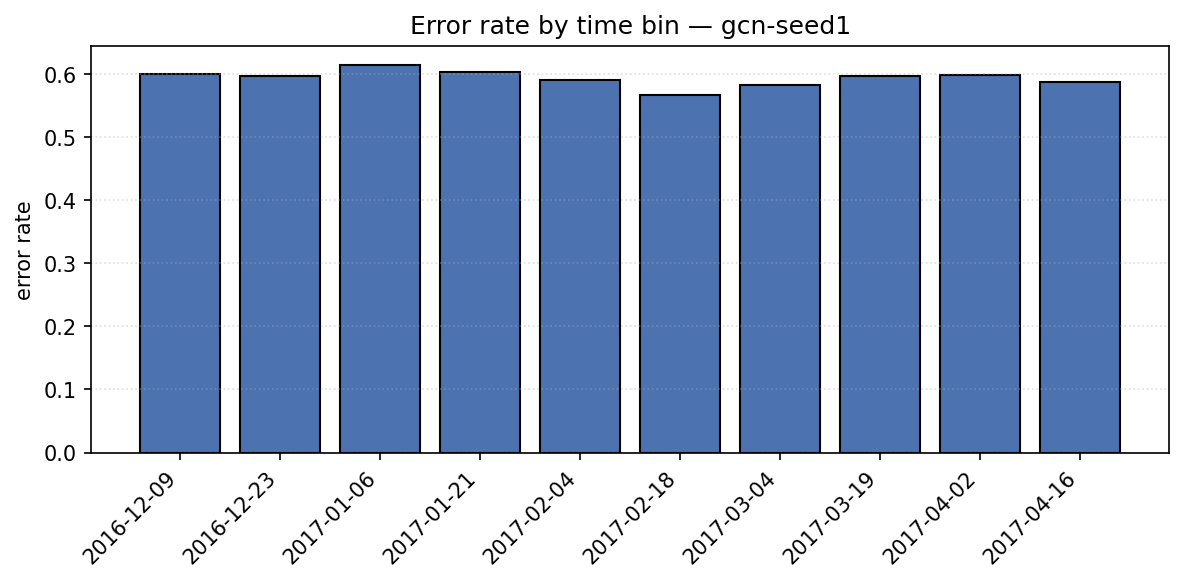

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_gcn-seed1.png


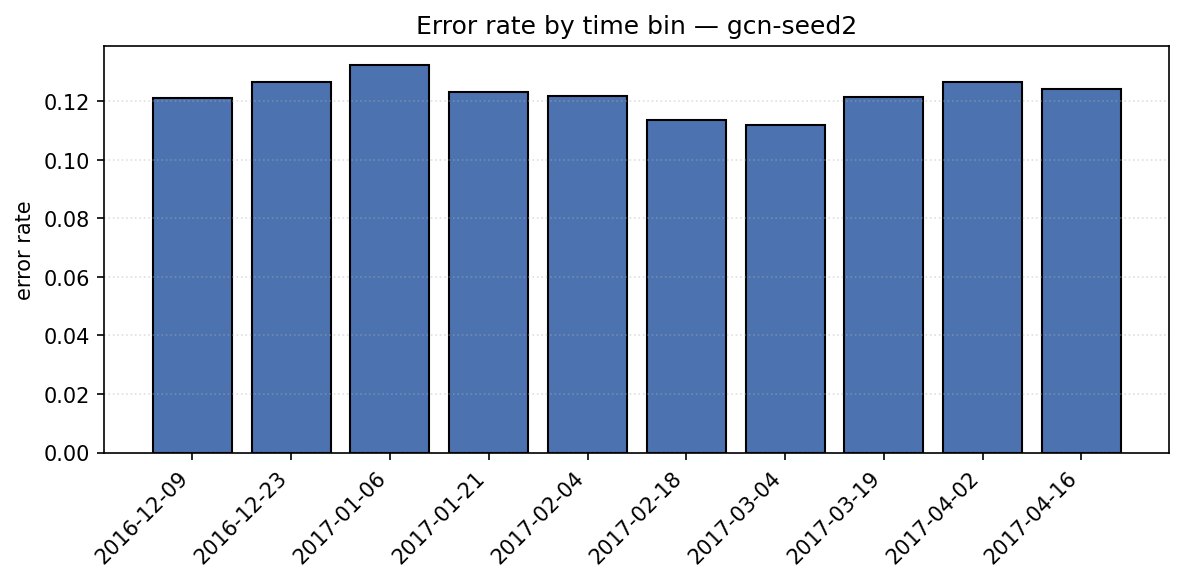

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_gcn-seed2.png


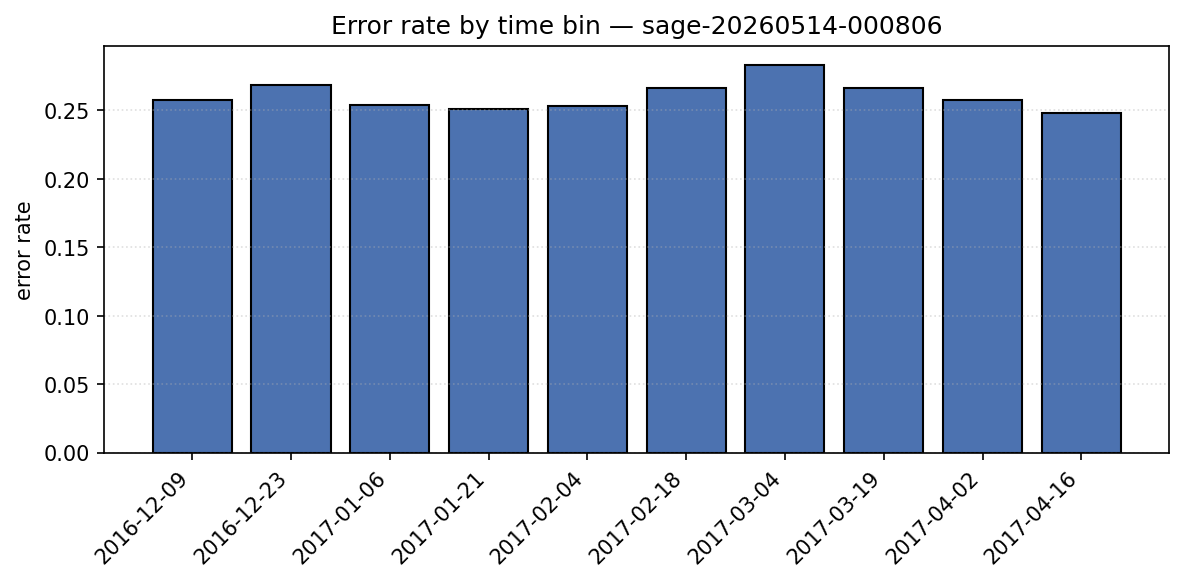

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_sage-20260514-000806.png


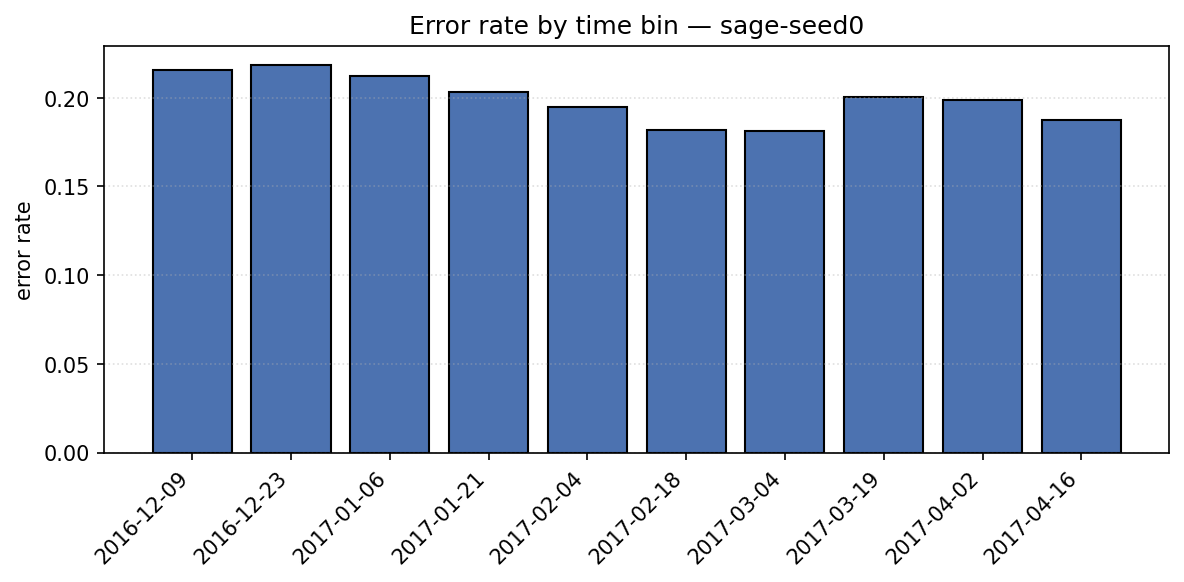

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_sage-seed0.png


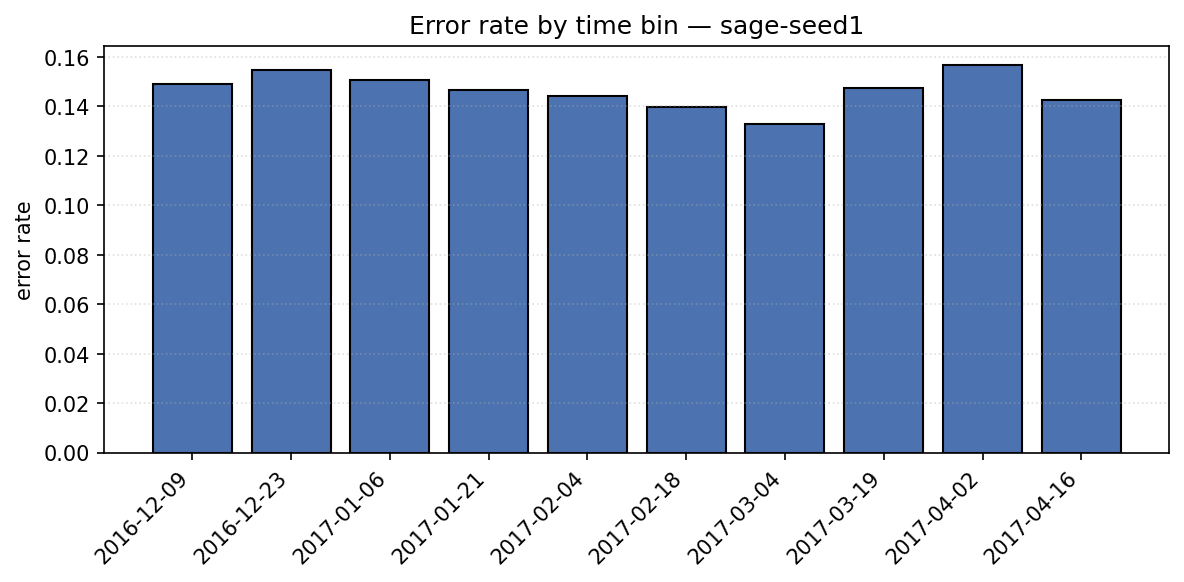

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_sage-seed1.png


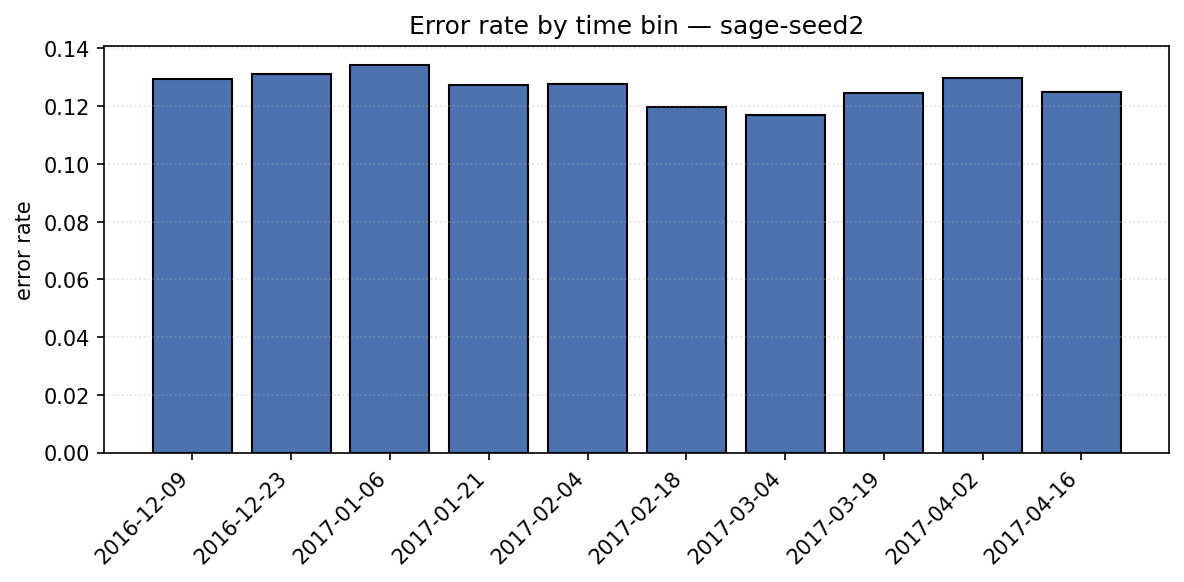

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_time_sage-seed2.png


In [3]:
for png in sorted(FIG_DIR.glob('error_by_time_*.png')):
    show_image_or_msg(png, png.name)
if not list(FIG_DIR.glob('error_by_time_*.png')):
    print('No error-by-time figures yet — run `make all`.')

## By-degree error rate

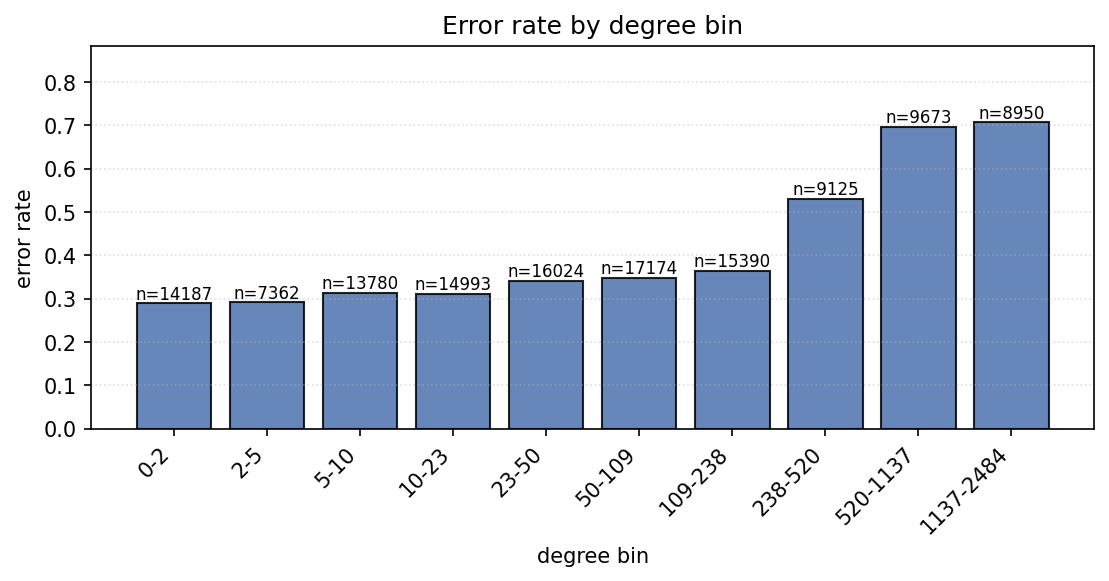

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_baseline_logreg-20260513-235620.png


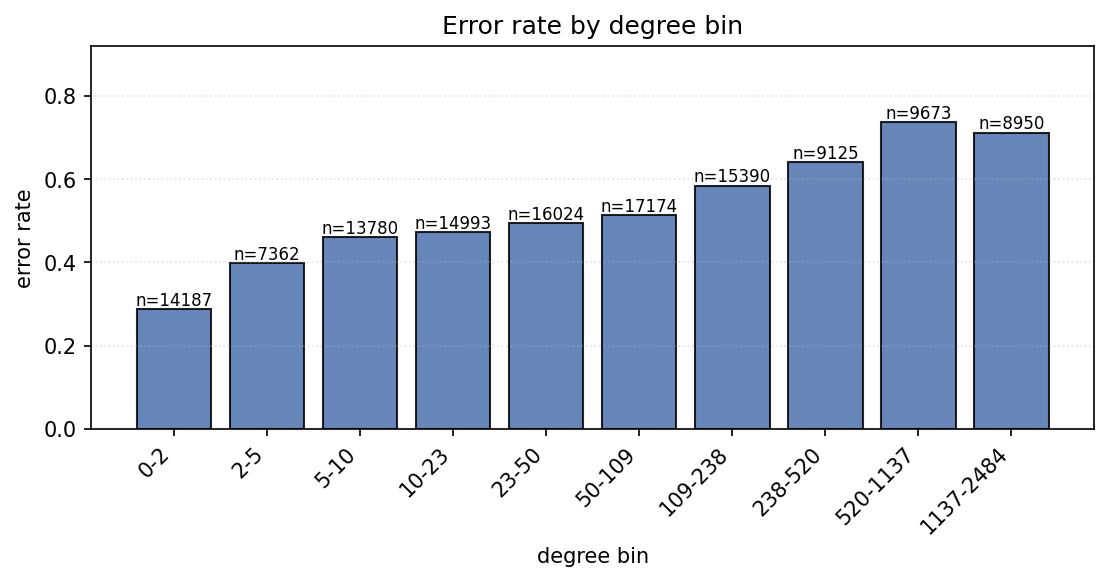

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_baseline_mlp-20260514-000355.png


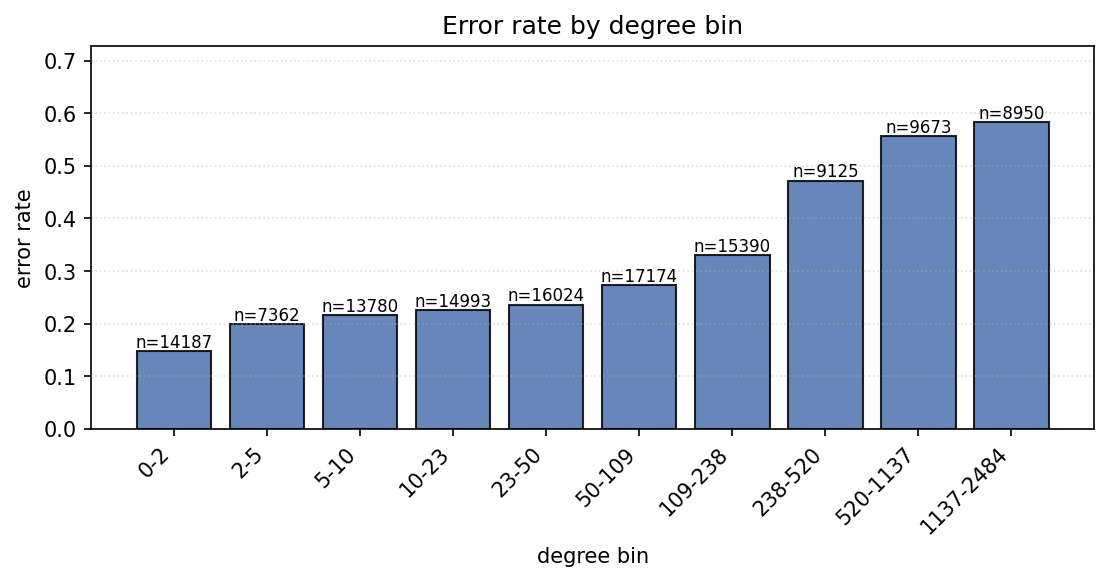

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_baseline_mlp-seed0.png


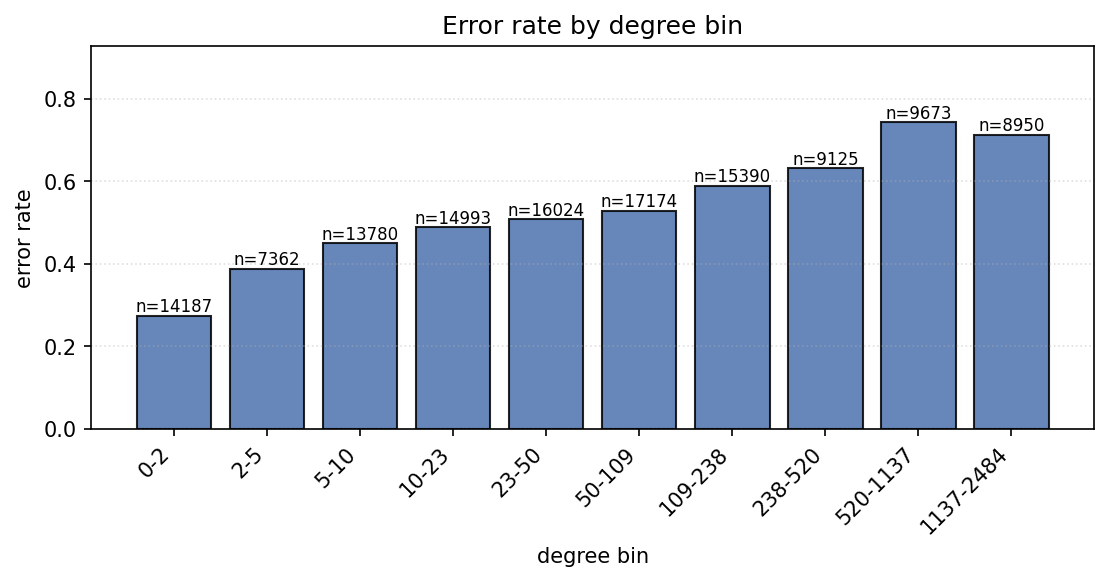

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_baseline_mlp-seed1.png


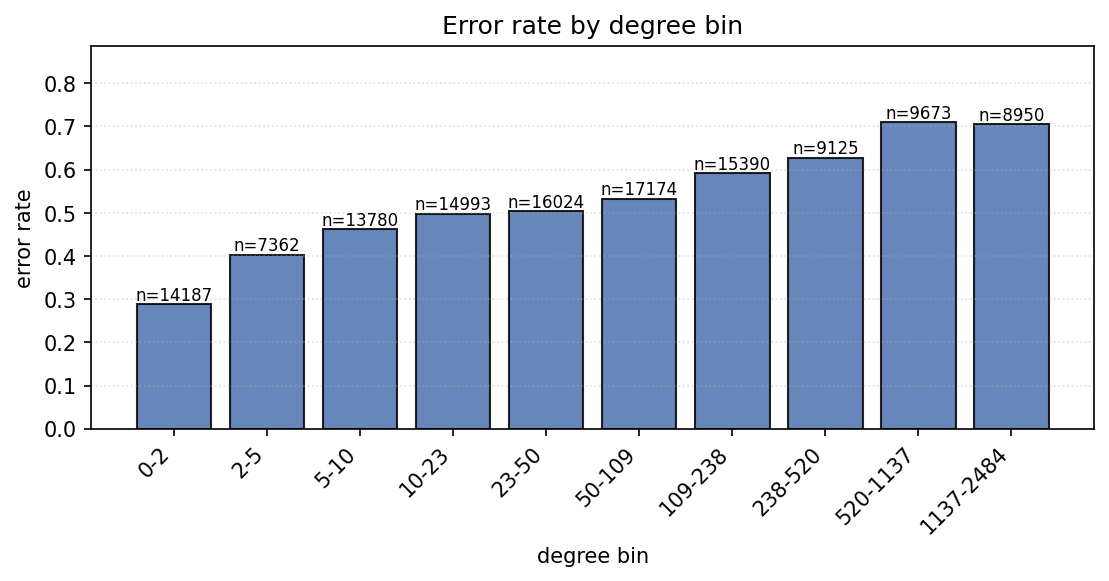

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_baseline_mlp-seed2.png


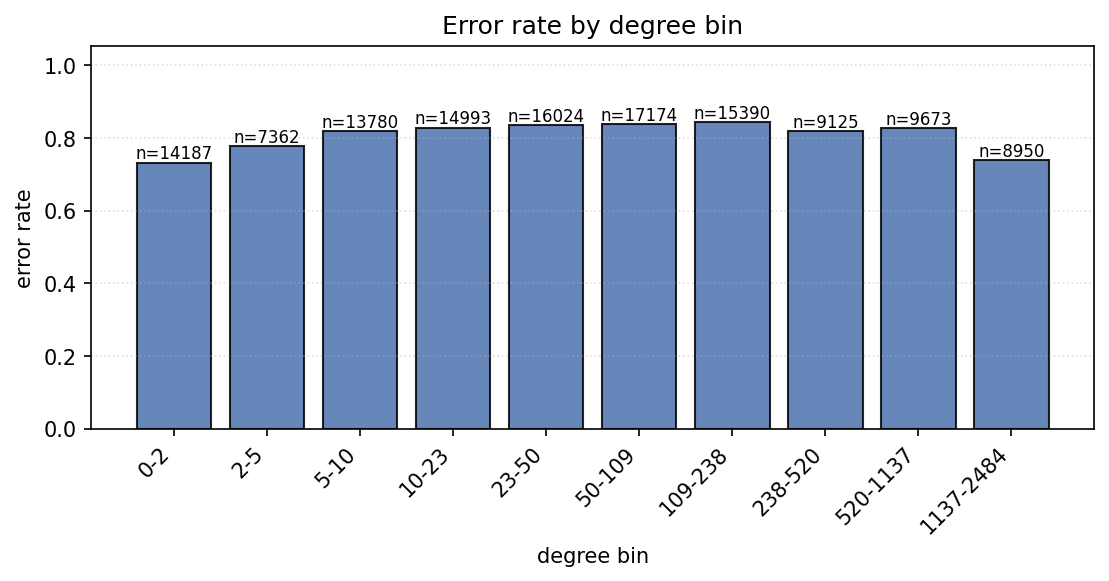

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_gat-20260514-001014.png


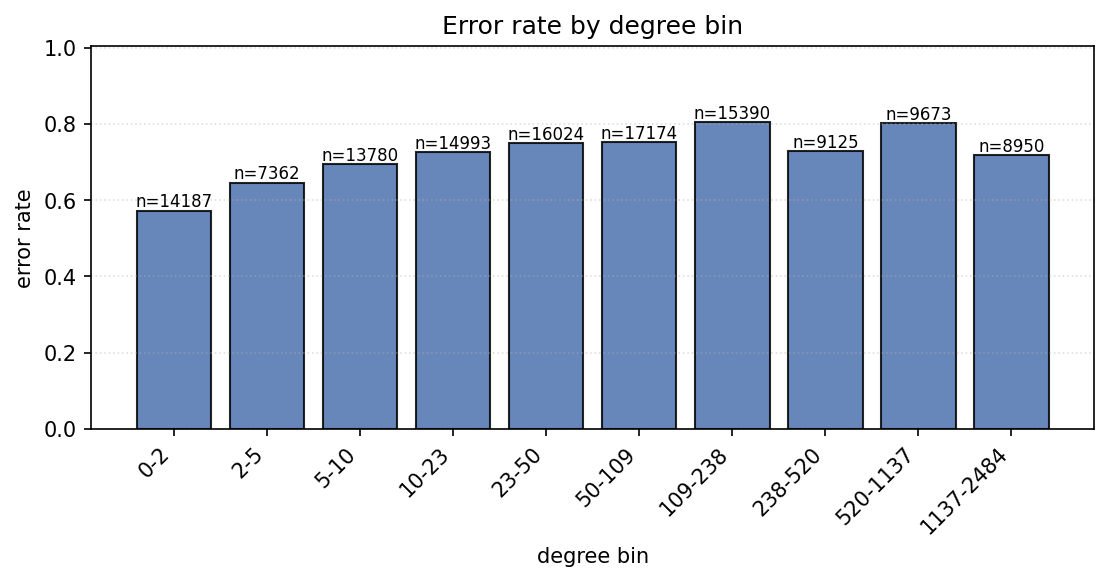

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_gat-seed0.png


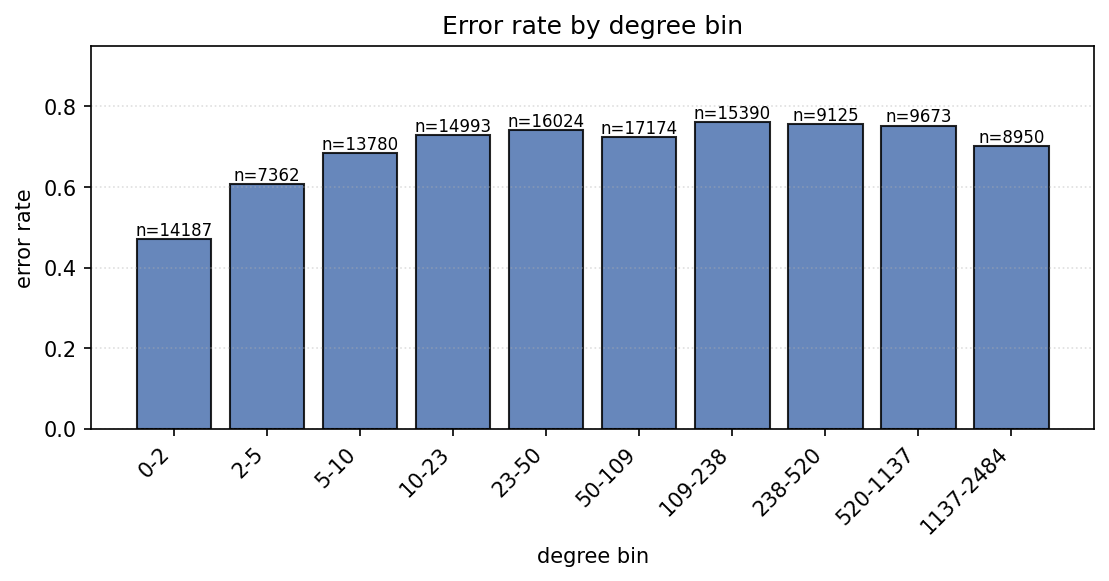

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_gat-seed1.png


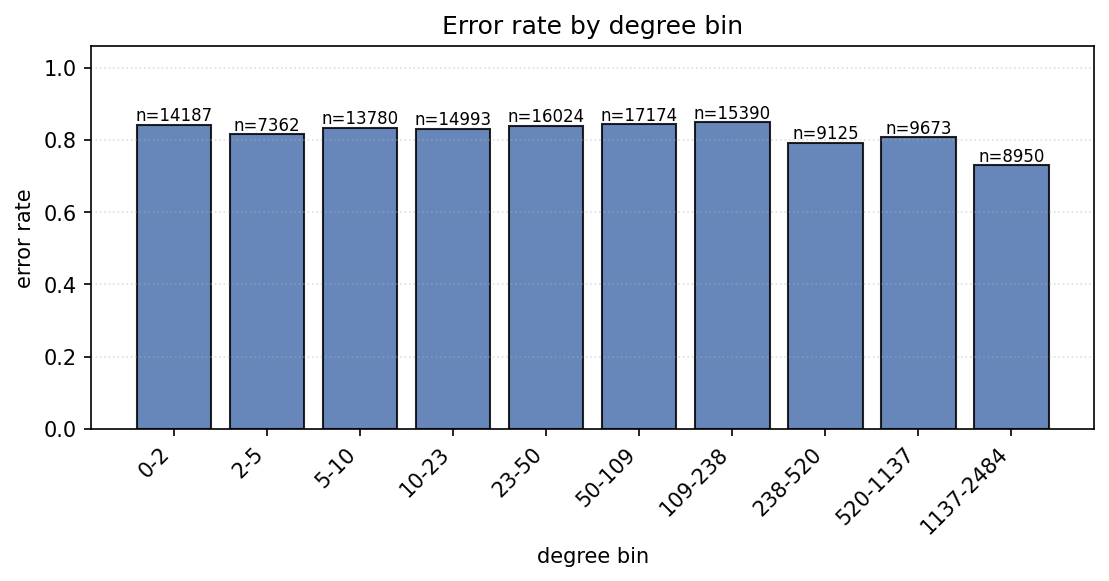

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_gat-seed2.png


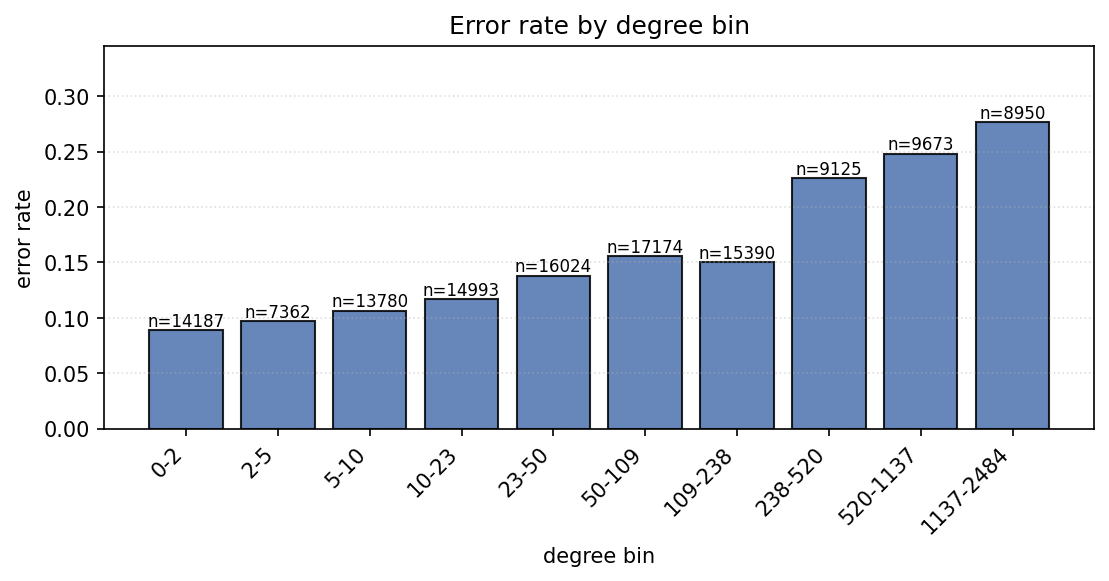

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_gcn-20260514-000537.png


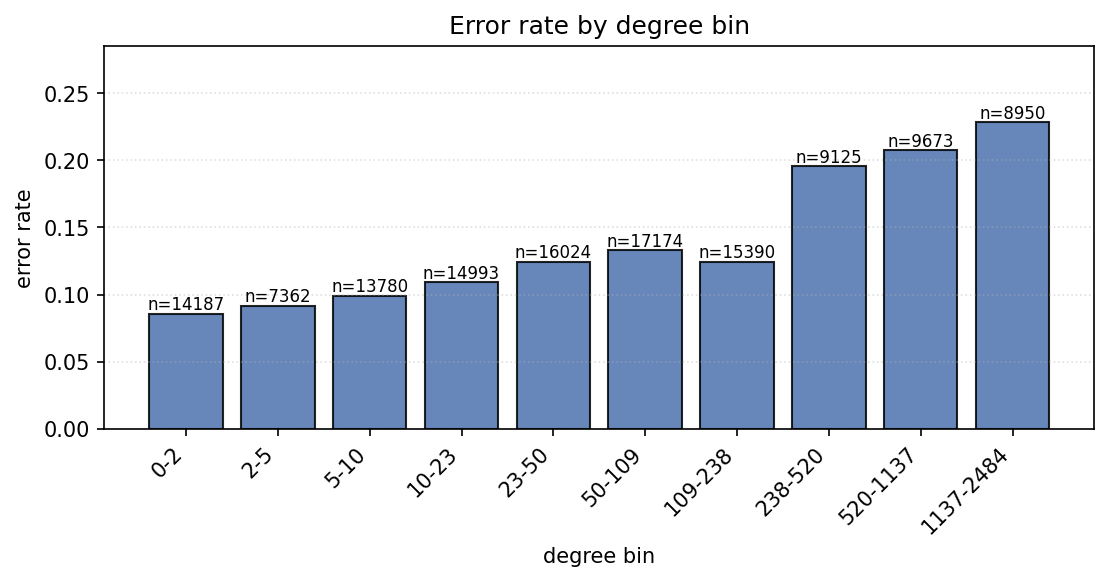

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_gcn-h128.png


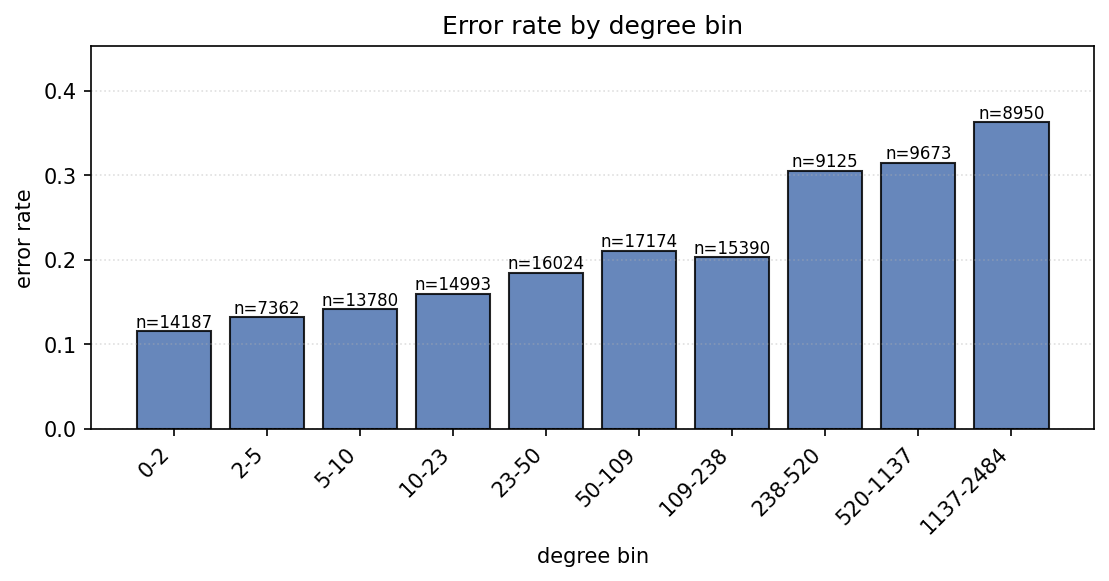

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_gcn-h256.png


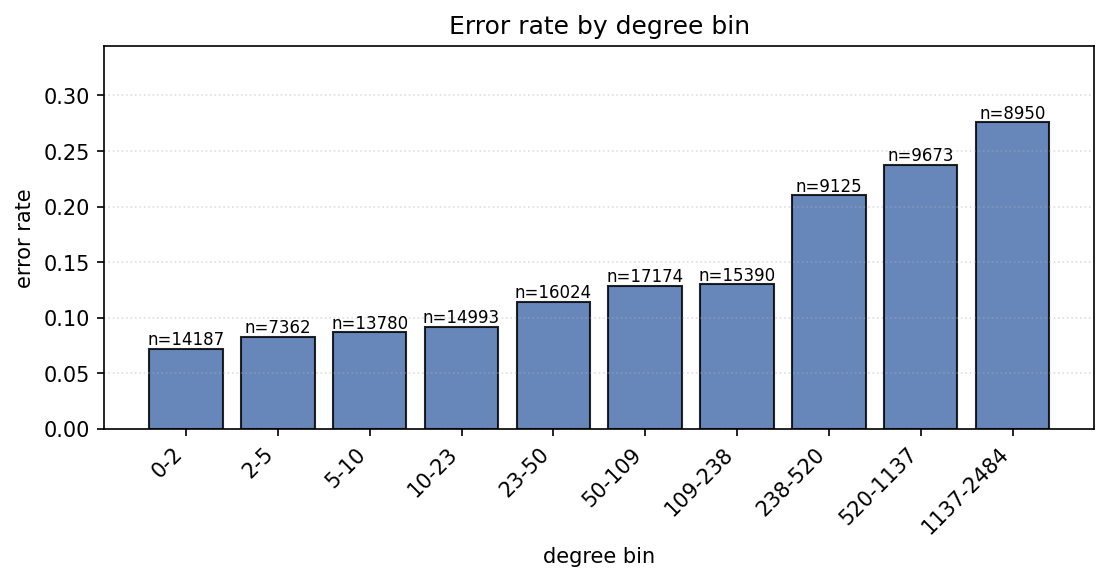

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_gcn-h64.png


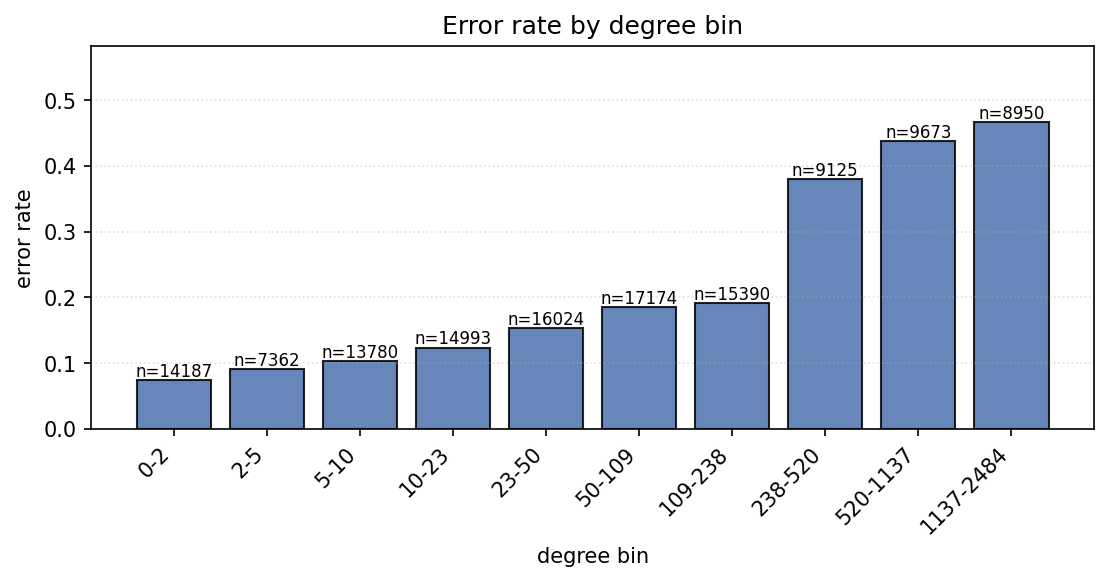

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_gcn-lr0.001.png


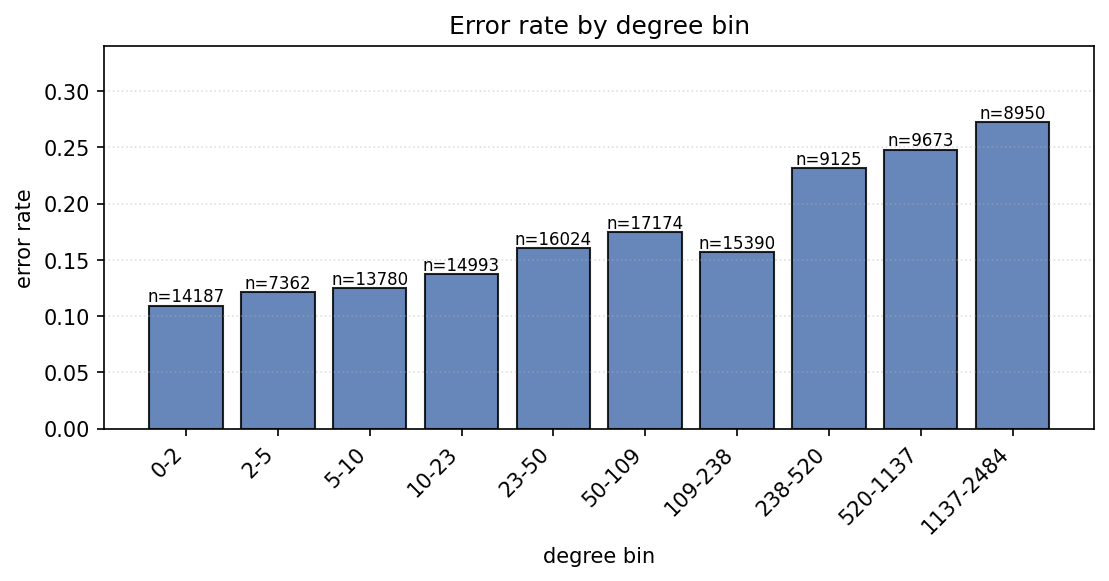

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_gcn-lr0.005.png


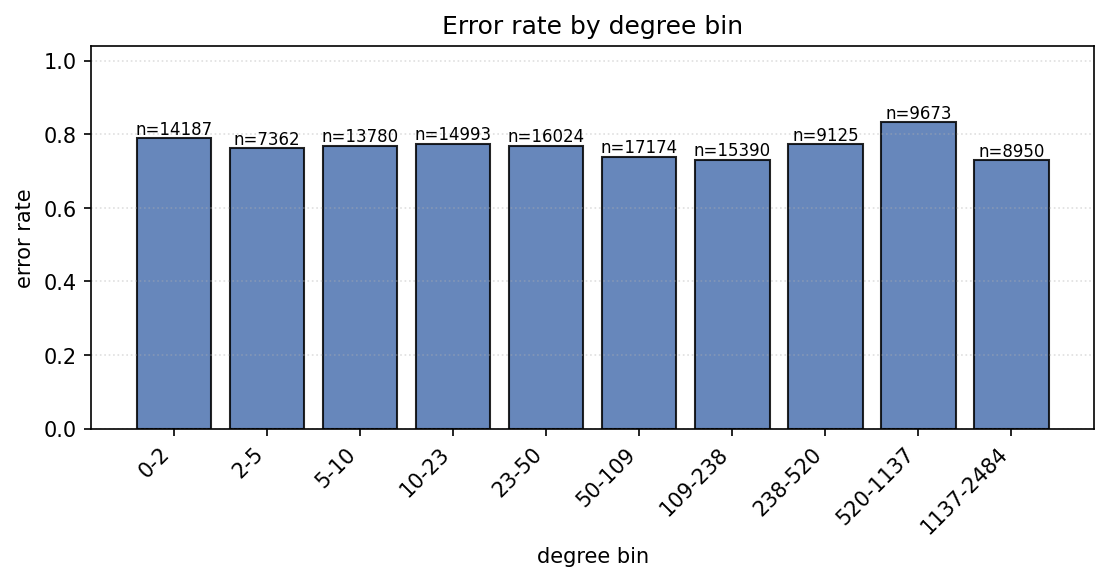

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_gcn-lr0.01.png


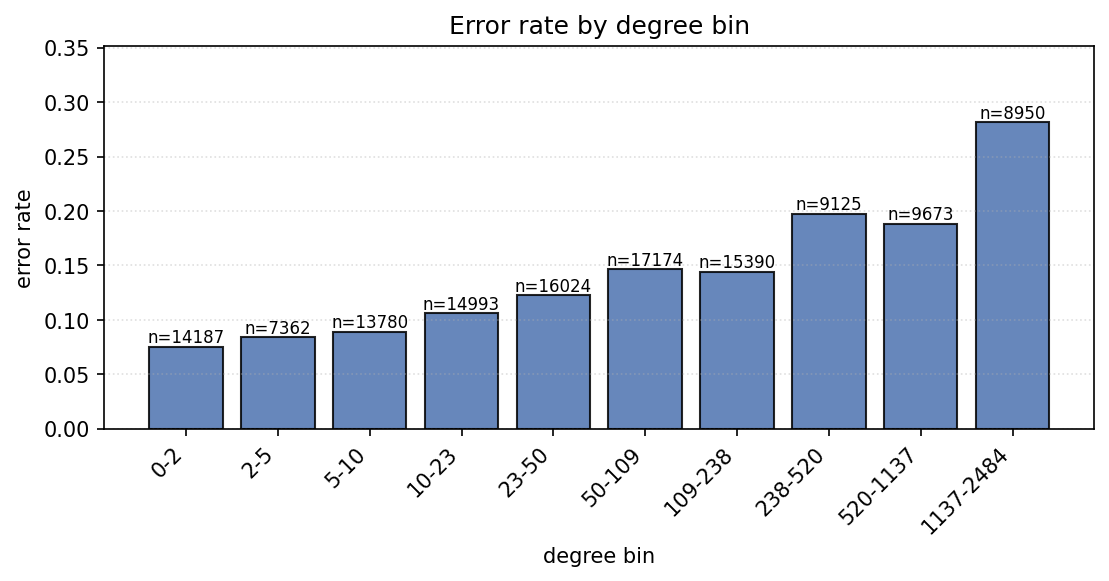

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_gcn-seed0.png


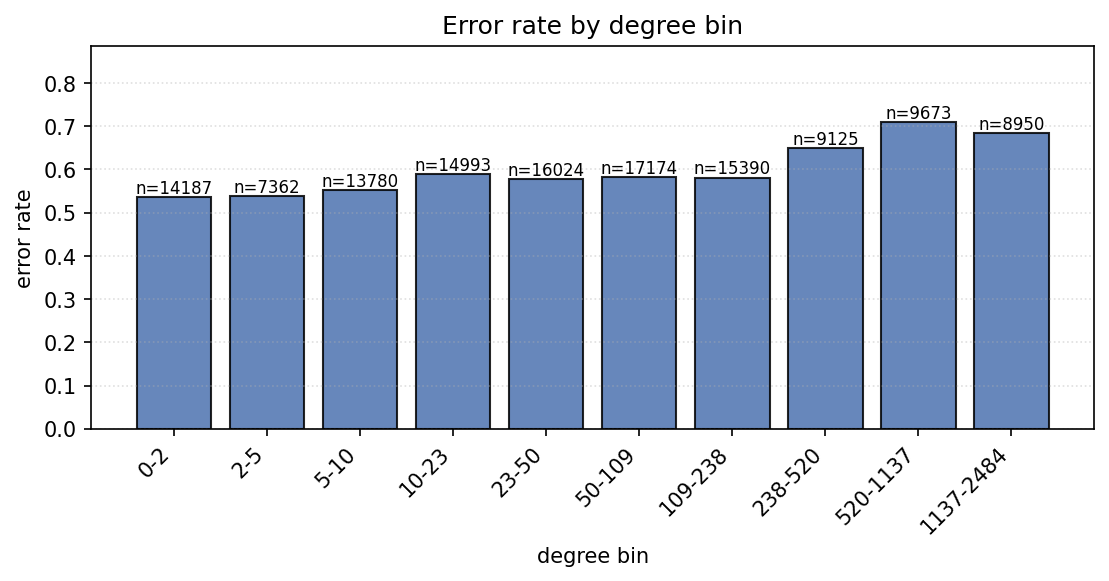

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_gcn-seed1.png


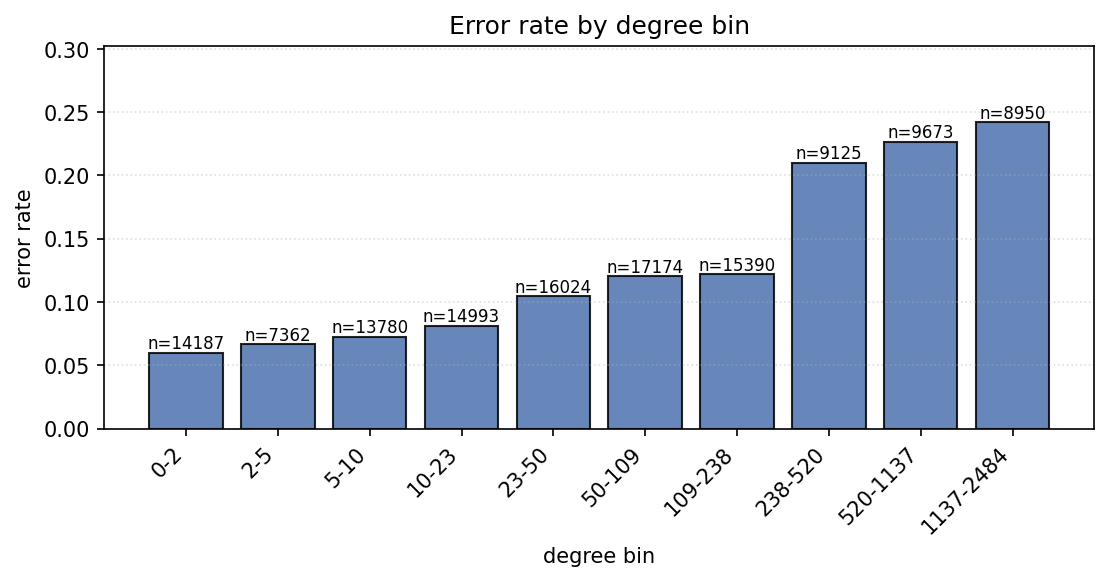

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_gcn-seed2.png


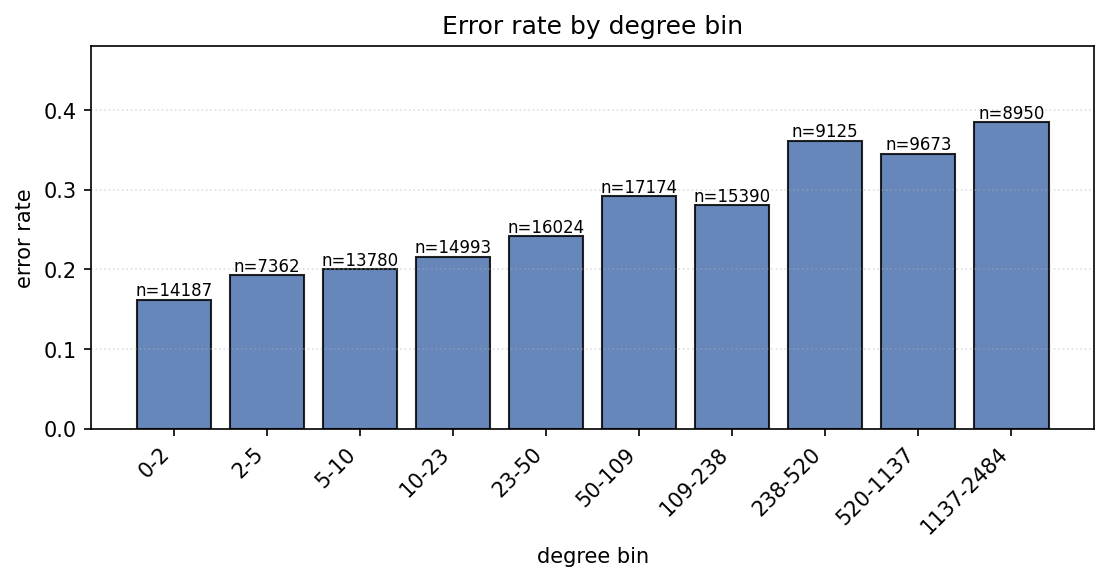

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_sage-20260514-000806.png


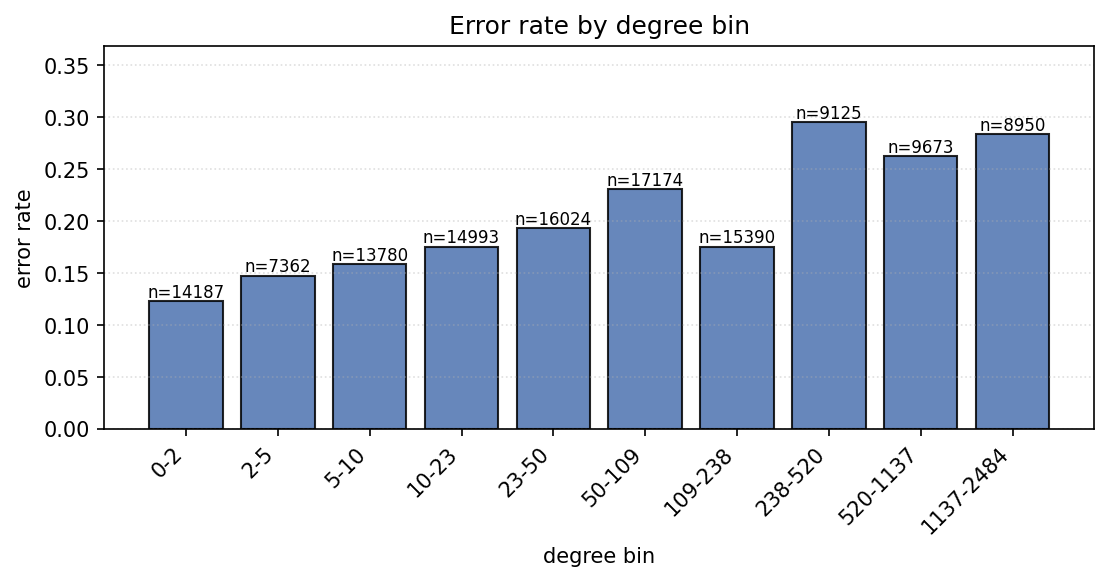

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_sage-seed0.png


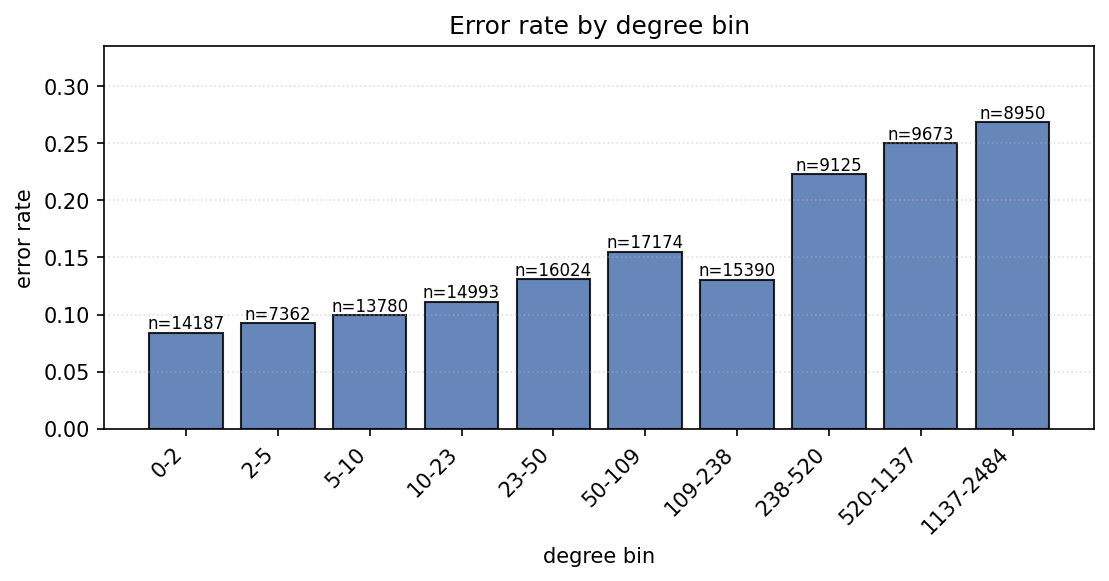

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_sage-seed1.png


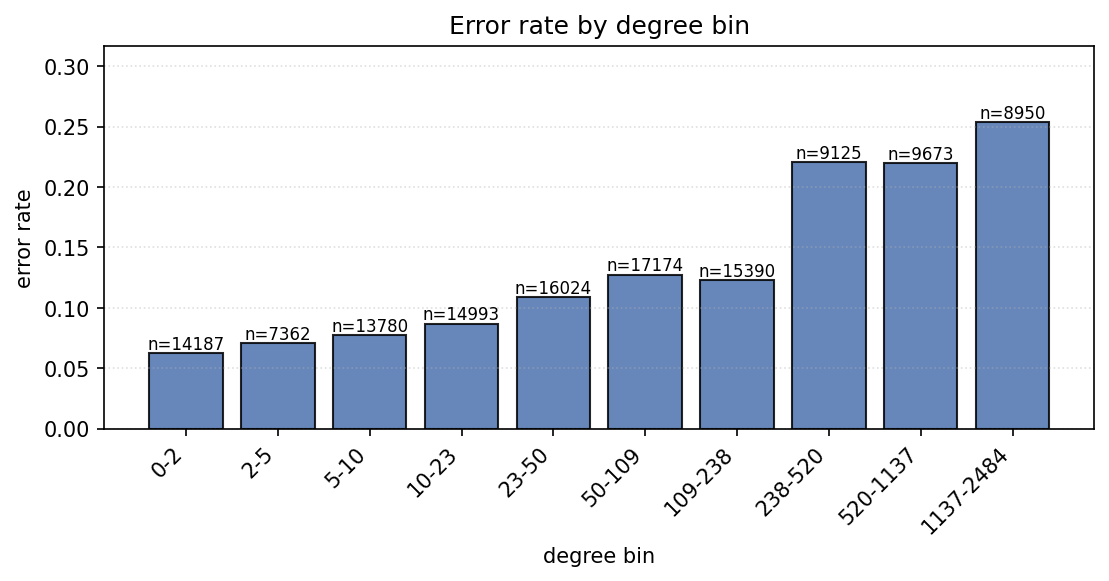

shown: /mnt/d/oleksandr/GNN/reports/figures/error_by_degree_sage-seed2.png


In [4]:
for png in sorted(FIG_DIR.glob('error_by_degree_*.png')):
    show_image_or_msg(png, png.name)
if not list(FIG_DIR.glob('error_by_degree_*.png')):
    print('No error-by-degree figures yet — run `make all`.')

## Model agreement matrix

Cohen's κ between every pair of trained models on the test split — high κ means the two models make similar predictions; low/negative κ means they disagree more than chance.

,baseline_logreg,baseline_mlp,gat,gcn,sage
baseline_logreg,1.000000,0.416878,0.065313,0.136527,0.173084
baseline_mlp,0.416878,1.000000,0.322280,0.087897,0.057832
gat,0.065313,0.322280,1.000000,0.046170,0.037094
gcn,0.136527,0.087897,0.046170,1.000000,0.616976
sage,0.173084,0.057832,0.037094,0.616976,1.000000


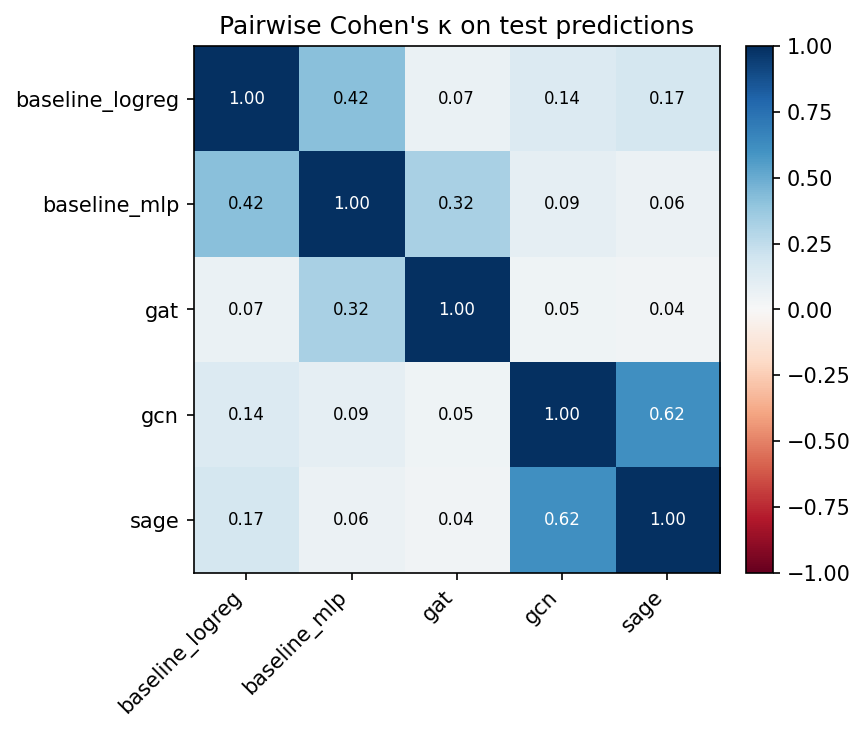

shown: /mnt/d/oleksandr/GNN/reports/figures/model_agreement.png


In [5]:
agreement_csv = TBL_DIR / 'model_agreement_kappa.csv'
agreement_png = FIG_DIR / 'model_agreement.png'
if agreement_csv.exists():
    display(pd.read_csv(agreement_csv, index_col=0))
else:
    print(f'Missing — run `make all` first: {agreement_csv}')
show_image_or_msg(agreement_png, agreement_png.name)

## Висновок

The export script populates both per-run breakdowns and the cross-model agreement matrix. Re-run `uv run python scripts/export_report_assets.py` after any new training experiment to refresh.